# Projeto da disciplina de Aprendizado de Máquina
## Criatura Lendária 1 - Cubo Gelatinoso

------

Docente: Daniel Roberto Cassar  
Discente: Maria Clara Costa Ferreira  

### Introdução

O cérebro apresenta uma grande diversidade de neurônios com diferentes propriedades eletrofisiológicas, morfológicas e localizações anatômicas. Essas características estão relacionadas à organização e funcionamento de diferentes regiões cerebrais e camadas do córtex, nomeadas de 1 a 6. O dataset "Cell Types Specimen" do Allen Institute possui dados experimentais de diversos neurônios de humanos e camundongos, incluindo informações sobre suas coordenadas exatas no cérebro.

Nessa perspectiva, o objetivo desse projeto é utilizar essas características para tentar prever a região cerebral de cada neurônio com um algoritmo de aprendizado de máquina K-Nearest-Neighbors (KNN). A classificação é baseada no acrônimo da estrutura, que na verdade é uma combinação entre a região e o nível cortical. Foram utilizados os atributos eletrofisiológicos e o identificador de espécie. Para avaliar diferentes configurações de modelo e selecionar aquelas com melhor desempenho, foi realizada uma otimização de parâmetros por meio de validação cruzada.

Além da avaliação do desempenho do modelo, as previsões foram usadas para representar os neurônios em uma visualização tridimensional do cérebro por meio da biblioteca Brainrender. Nessa representação, a localização real, obtida pelos dados experimentais, é comparada à localização prevista pelo modelo, permitindo ver espacialmente os acertos e erros da classificação e relacioná-los à anatomia cerebral.

### Bibliotecas

Para o desenvolvimento desse código foram utilizadas as seguintes bibliotecas:

In [1]:
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from brainrender.actors import Points
from brainrender import Scene
import pandas as pd
import seaborn as sns
import numpy as np
import random
import vedo
from matplotlib import pyplot as plt

Scikit-learn — utilizada para o desenvolvimento do modelo de classificação KNN, incluindo o pré-processamento dos dados, divisão entre conjuntos de treino e teste, otimização de hiperparâmetros e avaliação do desempenho do modelo.

Pandas — utilizada para leitura, organização, manipulação e análise dos dados.

NumPy — utilizada para operações numéricas e manipulação de arrays, incluindo as coordenadas dos neurônios.

Seaborn — utilizada para a criação de visualizações estatísticas, como mapas de calor e gráficos de desempenho.

Matplotlib — utilizada para criação e personalização de gráficos.

Brainrender— utilizada para a visualização tridimensional dos cérebros e dos neurônios, permitindo representar as regiões cerebrais associadas às classificações do modelo.

Vedo— utilizada como ferramenta de visualização e renderização 3D, dando suporte à representação gráfica utilizada pelo Brainrender.

Random  — utilizada para selecionar aleatoriamente neurônios do conjunto de teste para a visualização.

*********************************************************************************************************

### Análise exploratória dos dados

Inicialmente, é criado um dataframe a partir do dataset em formato de arquivo CSV. O dataframe, então, é exibido para uma visão geral de suas colunas e linhas, sendo identificados 2.333 neurônios.



In [2]:
dataset = "cell_types_specimen_details.csv"

df_celulas = pd.read_csv(dataset)
df_celulas

,line_name,specimen__id,specimen__name,specimen__hemisphere,structure__id,structure__name,structure__acronym,structure_parent__id,structure_parent__acronym,structure__layer,...,ephys_thumb_path,ephys_inst_thresh_thumb_path,donor__age,donor__sex,donor__disease_state,donor__race,donor__years_of_seizure_history,donor__species,donor__id,donor__name
0,NaN,525011903,H16.03.003.01.14.02,right,12113,"""frontal lobe""",FroL,12113,FroL,3,...,/api/v2/well_known_file_download/529903140,/api/v2/well_known_file_download/529903142,25 yrs,Male,epilepsy,White or Caucasian,9.0,Homo Sapiens,524848408,H16.03.003
1,Oxtr-T2A-Cre,565871768,Oxtr-2A-Cre;Ai14-293837.03.01.02,left,778,"""Primary visual area, layer 5""",VISp5,385,VISp,5,...,/api/v2/well_known_file_download/566738214,/api/v2/well_known_file_download/566738219,NaN,NaN,NaN,NaN,NaN,Mus musculus,563340157,Oxtr-T2A-Cre;Ai14-293837
2,Pvalb-IRES-Cre,469801138,Pvalb-IRES-Cre;Ai14-170927.05.02.01,right,721,"""Primary visual area, layer 4""",VISp4,385,VISp,4,...,/api/v2/well_known_file_download/487618917,/api/v2/well_known_file_download/491380580,NaN,NaN,NaN,NaN,NaN,Mus musculus,319194354,Pvalb-IRES-Cre;Ai14(IVSCC)-170927
3,NaN,528642047,H16.06.009.01.02.06.05,left,12141,"""middle temporal gyrus""",MTG,12141,MTG,5,...,/api/v2/well_known_file_download/660970973,/api/v2/well_known_file_download/660970975,48 yrs,Female,epilepsy,unknown,33.0,Homo Sapiens,528574320,H16.06.009
4,Slc32a1-T2A-FlpO|Vipr2-IRES2-Cre,605889373,Vipr2-IRES2-Cre;Slc32a1-T2A-FlpO;Ai65-337419.0...,right,821,"""Primary visual area, layer 2/3""",VISp2/3,385,VISp,2/3,...,/api/v2/well_known_file_download/657612184,/api/v2/well_known_file_download/657612186,NaN,NaN,NaN,NaN,NaN,Mus musculus,605622695,Vipr2-IRES2-Cre;Slc32a1-T2A-FlpO;Ai65-337419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2328,NaN,601958555,H17.03.010.11.13.06,left,12141,"""middle temporal gyrus""",MTG,12141,MTG,4,...,/api/v2/well_known_file_download/606116041,/api/v2/well_known_file_download/606116043,38 yrs,Female,epilepsy,unknown,11.0,Homo Sapiens,601901227,H17.03.010
2329,Rorb-IRES2-Cre,488473535,Rorb-IRES2-Cre-D;Ai14-212867.03.01.01,left,821,"""Primary visual area, layer 2/3""",VISp2/3,385,VISp,2/3,...,/api/v2/well_known_file_download/488474970,/api/v2/well_known_file_download/491376689,NaN,NaN,NaN,NaN,NaN,Mus musculus,487607572,Rorb-IRES2-Cre-D;Ai14-212867
2330,Rorb-IRES2-Cre,467003163,Rorb-IRES2-Cre-D;Ai14-172652.02.02.01,right,721,"""Primary visual area, layer 4""",VISp4,385,VISp,4,...,/api/v2/well_known_file_download/487623212,/api/v2/well_known_file_download/491378303,NaN,NaN,NaN,NaN,NaN,Mus musculus,322489498,Rorb-IRES2-Cre-D;Ai14(IVSCC)-172652
2331,Pvalb-IRES-Cre,572609946,Pvalb-IRES-Cre;Ai14-301945.04.02.01,right,721,"""Primary visual area, layer 4""",VISp4,385,VISp,4,...,/api/v2/well_known_file_download/575795570,/api/v2/well_known_file_download/575795572,NaN,NaN,NaN,NaN,NaN,Mus musculus,570930952,Pvalb-IRES-Cre;Ai14-301945


Analisando mais detalhadamente as colunas, identificam-se como atributos inúmeras propriedades morfológicas, eletrofisiológicas (as colunas que começam com "ef__"), especificadores sobre a localização do neurônio e características de seu doador.

In [3]:
df_celulas.columns


Index(['line_name', 'specimen__id', 'specimen__name', 'specimen__hemisphere',
       'structure__id', 'structure__name', 'structure__acronym',
       'structure_parent__id', 'structure_parent__acronym', 'structure__layer',
       'nr__max_euclidean_distance', 'nr__number_stems',
       'nr__number_bifurcations', 'nr__average_contraction',
       'nr__average_parent_daughter_ratio', 'nr__reconstruction_type',
       'nrwkf__id', 'erwkf__id', 'ef__fast_trough_v_long_square',
       'ef__upstroke_downstroke_ratio_long_square', 'ef__adaptation',
       'ef__f_i_curve_slope', 'ef__threshold_i_long_square', 'ef__tau',
       'ef__avg_isi', 'ef__avg_firing_rate', 'ef__ri', 'ef__peak_t_ramp',
       'ef__vrest', 'si__height', 'si__width', 'si__path', 'csl__x', 'csl__y',
       'csl__z', 'csl__normalized_depth', 'cell_reporter_status', 'm__glif',
       'm__biophys', 'm__biophys_perisomatic', 'm__biophys_all_active',
       'tag__apical', 'tag__dendrite_type', 'morph_thumb_path',
       'ephys

<details>
<summary> Descrição de cada atributo </summary>
Atributos relacionados a identificação, linhagem e origem

* line_name: Nome da linhagem de camundongo transgênico (ex: Cux2-CreERT2), usada para marcar tipos celulares específicos.
* specimen__id: Identificador numérico único de cada célula/amostra individual.
* specimen__name: Código ou nome em texto dado à célula no laboratório.
* specimen__hemisphere: Hemisfério cerebral de onde o neurônio foi extraído (Esquerdo ou Direito).

Localização Anatômica e Estrutural

* structure__id: ID numérico da estrutura anatômica no atlas do Allen Institute.
* structure__name: Nome por extenso da área cerebral (ex: Visual Cortex).
* structure__acronym: Sigla da estrutura anatômica (ex: VISp para Córtex Visual Primário).
* structure_parent__id: ID da região maior que engloba a estrutura atual.
* structure_parent__acronym: Sigla da região maior (ex: CTX para Córtex).
* structure__layer: A camada cortical exata onde a célula estava localizada (ex: Camada 4, Camada 5).

Morfologia

* nr__max_euclidean_distance: Maior distância em linha reta do corpo celular até a ponta de qualquer ramificação.
* nr__number_stems: Quantidade de troncos principais que brotam diretamente do corpo da célula (soma).
* nr__number_bifurcations: Número de vezes que os ramos da célula se dividiram em dois.
* nr__average_contraction: Nível de curvatura dos ramos (valores menores indicam prolongamentos mais tortuosos).
* nr__average_parent_daughter_ratio: Razão de diâmetro média entre um ramo principal e suas ramificações filhas.
* nr__reconstruction_type: Tipo de reconstrução 3D realizada (manual assistida por computador ou automática).

Identificadores de Fluxo Técnico

* nrwkf__id: ID do fluxo de trabalho técnico para o processamento dos dados de morfologia.
* erwkf__id: ID do fluxo de trabalho técnico para o processamento dos dados de eletrofisiologia.

Eletrofisiologia

* ef__fast_trough_v_long_square: Voltagem do ponto mais baixo (vale) logo após o disparo de um potencial de ação.
* ef__upstroke_downstroke_ratio_long_square: Razão entre a velocidade máxima de subida e descida do pulso elétrico.
* ef__adaptation: Taxa de desaceleração dos disparos da célula sob um estímulo elétrico contínuo.
* ef__f_i_curve_slope: Ganho elétrico da célula (quantos disparos ela ganha por pico de corrente injetada).
* ef__threshold_i_long_square: Corrente mínima necessária para o neurônio começar a disparar.
* ef__tau: Constante de tempo que a membrana celular leva para se carregar eletricamente.
* ef__avg_isi: Tempo médio que passa entre um disparo elétrico e o próximo (Inter-Spike Interval).
* ef__avg_firing_rate: Frequência média de disparos (impulsos elétricos por segundo).
* ef__ri: Resistência elétrica de entrada da membrana celular.
* ef__peak_t_ramp: O tempo exato do primeiro disparo sob uma corrente que sobe de forma linear (rampa).
* ef__vrest: Potencial elétrico de repouso (a voltagem natural do neurônio quando desativado).

Imagens do tecido e Localização Espacial das Células

* i__height: Altura em pixels da imagem microscópica da fatia de tecido.
* si__width: Largura em pixels da imagem microscópica da fatia de tecido.
* si__path: Caminho do arquivo da imagem microscópica original no servidor.
* csl__x: Coordenada espacial X da célula no espaço cerebral.
* csl__y: Coordenada espacial Y da célula no espaço cerebral.
* csl__z: Coordenada espacial Z da célula no espaço cerebral.
* csl__normalized_depth: Profundidade proporcional dentro do córtex cerebral (vai de 0 a 1).

Marcadores Genéticos e Modelagem Computacional

* cell_reporter_status: Indica se a célula expressava coloração fluorescente (positiva/negativa) sob microscopia.
* m__glif: ID do modelo computacional simplificado do tipo Generalized Leak-Integrate-and-Fire.
* m__biophys: ID do modelo biofísico computacional básico.
* m__biophys_perisomatic: ID do modelo biofísico focado no comportamento ao redor do corpo celular.
* m__biophys_all_active: ID do modelo biofísico complexo onde todas as partes da célula possuem canais ativos virtuais.

Características Visuais e Miniaturas (Thumbnails)
 
* tag__apical: Status do dendrito apical (indica se a árvore dendrítica principal está intacta ou foi cortada na fatia).
* tag__dendrite_type: Classificação morfológica baseada na presença de espinhos (ex: spiny, aspiny).
* morph_thumb_path: Caminho/link para a miniatura da imagem da reconstrução 3D da forma do neurônio.
* ephys_thumb_path: Caminho/link para a miniatura do gráfico das ondas de disparos elétricos.
* ephys_inst_thresh_thumb_path: Caminho/link para a miniatura do gráfico do limiar de disparo instantâneo.

Informações Demográficas e Clínicas do Doador

* donor__age: Idade do doador no momento da coleta do tecido.
* donor__sex: Sexo biológico do doador (Masculino/Feminino).
* donor__disease_state: Condição clínica do doador (ex: se possuía alguma patologia que justificasse a cirurgia).
* donor__race: Raça ou etnia declarada do doador (aplicável a amostras humanas).
* donor__years_of_seizure_history: Quantidade de anos que o doador sofria com convulsões/epilepsia.
* donor__species: Espécie do doador (geralmente Homo sapiens ou Mus musculus).
* donor__id: Identificador único do doador do tecido no banco de dados.
* donor__name: Nome codificado atribuído ao doador.

A descrição das 54 colunas desse DataFrame foi realizada com o auxílio de Inteligência Artificial por razões de eficiência. Como o DataFrame possui atributos altamente especializados de diferentes subáreas da neurociência, uma catalogação manual iria exigir uma busca minuciosa em inúmeros dicionários de dados, glossários de APIs e artigos do Allen Institute. O uso da tecnologia otimizou o tempo de análise e permitiu que o foco do projeto fosse direcionado para as etapas de análise exploratória e construção do modelo preditivo.

A seguir, observa-se quais condições neurológicas estão presentes nos doadores de cada célula.

Text(0.5, 1.0, 'Condições neurológicas entre os dados')

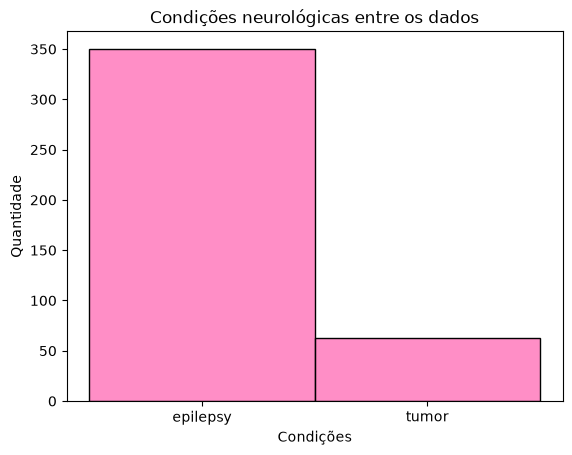

In [4]:
condicoes = df_celulas["donor__disease_state"]

# Cria histograma
eixo = sns.histplot(condicoes, discrete = True, color = "hotpink")
eixo.set_xlabel("Condições")
eixo.set_ylabel("Quantidade")
eixo.set_title("Condições neurológicas entre os dados")

O gráfico apresenta cerca de 350 células cujos doadores possuíam epilepsia e mais de 50 células provenientes de indivíduos com tumores cerebrais. Essa informação é importante pois tanto a epilepsia quanto tumores cerebrais estão associados à hiperexcitabilização dos neurônios.

A epilepsia altera os mecanismos de disparo do próprio neurônio (falhas nos canais iônicos e nos gradientes de sódio e potássio[17], enquanto os tumores podem amplificar a atividade elétrica dos neurônios através de sinapses Neuro-Glioma [11].

Como os atributos eletrofisiológicos desse dataset dizem respeito justamente a como os neurônios respondem eletricamente, essas alterações na excitabilidade podem aparecer como diferenças nesses parâmetros.

No gráfico abaixo, computa-se quantas células são de ratos e quantas tem origem humana.

Text(0.5, 1.0, 'Distribuição entre humanos e ratos')

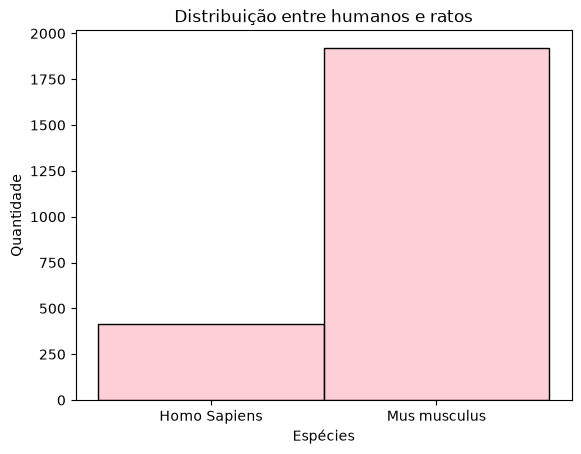

In [5]:
especies = df_celulas["donor__species"]

# Cria histograma
eixo = sns.histplot(especies, discrete = True, color = "pink")
eixo.set_xlabel("Espécies")
eixo.set_ylabel("Quantidade")
eixo.set_title("Distribuição entre humanos e ratos")

O termo "Homo Sapiens" se refere à espécie humana, enquanto "Mus musculus" diz respeito a camundongos (também chamados de ratos-domésticos). Nota-se que a maioria das células vem de ratos.

Em seguida, computa-se um gráfico para relacionar as médias de potenciais de ação (impulsos elétricos) por segundo com as duas espécies.

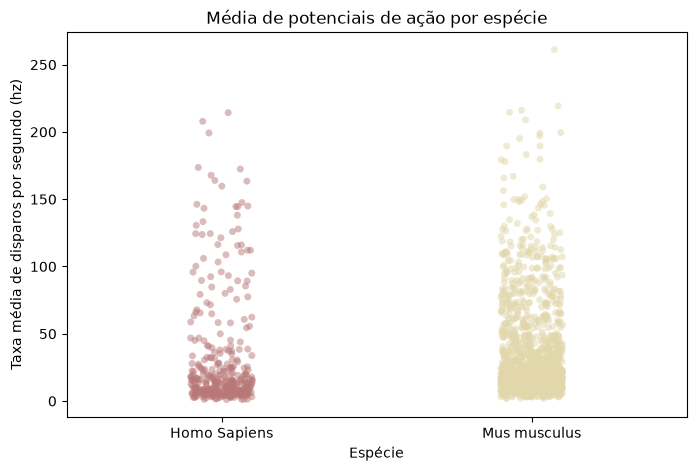

In [6]:
plt.figure(figsize=(8,5))
sns.stripplot(
    data = df_celulas,
    x = "donor__species",
    y = "ef__avg_firing_rate",
    hue = "donor__species",
    alpha = 0.5,
    palette = "pink",
)
plt.xlabel("Espécie")
plt.ylabel("Taxa média de disparos por segundo (hz)")
plt.title("Média de potenciais de ação por espécie")
plt.show()

Apesar de o número de neurônios de ratos ser bem maior, é possível identificar uma certa diferença nessa distribuição entre as espécies: os pontos que representam neurônios de ratos se acumulam em camadas mais altas em comparação com os de humanos, indicando taxas médias de disparos por segundo maiores.

Isso é, na verdade, um fato científico interessante: neurônios de camundongos tendem a disparar em frequências basais (em repouso) e máximas mais altas que as de neurônios humanos [20]. Existem muitos motivos para isso, mas a menor densidade de canais iônicos em humanos é um deles [16]. Como consequência, menos energia é gasta por potencial de ação, o que faz com que neurônios humanos sejam eletricamente mais eficientes.

Dando prosseguimento, a relação entre a morfologia dos dendritos e propriedades elétricas é bem estabelecida teoricamente, abaixo computa-se um gráfico para investigar se essa relação aparece nos dados do Allen Cell Types Database, através do número de bifurcações e da resistência interna:

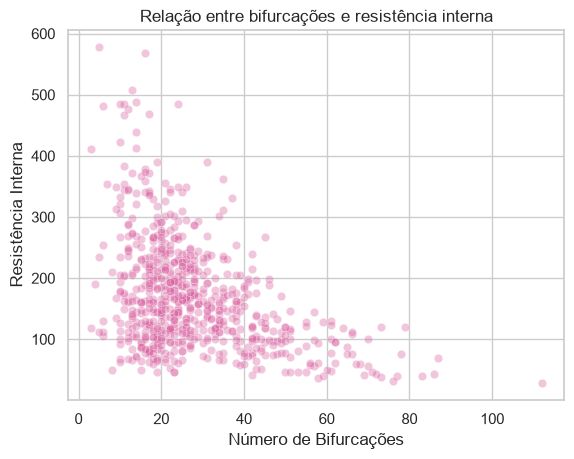

In [7]:
sns.set_theme(style="whitegrid")
sns.scatterplot(
    data = df_celulas,
    x = "nr__number_bifurcations",
    y = "ef__ri",
    alpha = 0.36,
    color = "#D95F9F"
)

#Cria o gráfico

plt.xlabel("Número de Bifurcações")
plt.ylabel("Resistência Interna")
plt.title("Relação entre bifurcações e resistência interna")

plt.show()

Pode-se observar uma tendência entre o número de bifurcações de um neurônio e sua resistência interna que indica que, à medida que o número de bifurcações aumenta, a resistência interna diminui. Isso pode ocorrer pois, apesar de geralmente cada ramo criado por uma bifurcação ser mais fino que o ramo que o originou, o surgimento de muitas ramificações em paralelo permite que a corrente se distribua por diversos ramos diferentes.

**************************************************************************************

### Construção do modelo preditivo

Para a criação do algoritmo KNN, os atributos (propriedades eletrofisiológicas e espécie) e o target a ser previsto (região do neurônio) são escolhidos.  
Através da função ".reindex()", essas colunas são filtradas e usadas para criar um outro DataFrame na ordem de colunas especificada (primeiro atributos e no final o target). O argumento axis = 1 é o que faz com que essa reorganização ocorra apenas nas colunas.  Depois, as linhas com dados faltantes são eliminadas.

In [8]:
ATRIBUTOS = [
    "ef__fast_trough_v_long_square","ef__upstroke_downstroke_ratio_long_square", "ef__adaptation",
    "ef__f_i_curve_slope", "ef__threshold_i_long_square", "ef__tau", "ef__avg_isi", "ef__avg_firing_rate",
    "ef__ri", "ef__peak_t_ramp", "ef__vrest", "donor__species"
    ]

TARGET = ["structure__acronym"]

df_knn = df_celulas.reindex(ATRIBUTOS + TARGET, axis=1)
df_knn = df_knn.dropna()
df_knn

,ef__fast_trough_v_long_square,ef__upstroke_downstroke_ratio_long_square,ef__adaptation,ef__f_i_curve_slope,ef__threshold_i_long_square,ef__tau,ef__avg_isi,ef__avg_firing_rate,ef__ri,ef__peak_t_ramp,ef__vrest,donor__species,structure__acronym
0,-53.875004,2.895461,0.027846,0.167187,90.0,21.181026,73.678333,13.572511,159.531131,4.104107,-70.561035,Homo Sapiens,FroL
2,-55.687504,1.162618,0.000643,1.156789,290.0,4.121689,12.507500,79.952029,65.624997,11.763022,-72.042976,Mus musculus,VISp4
4,-47.093754,3.379321,-0.015098,0.191853,280.0,5.166574,78.950909,12.666099,102.968708,8.423400,-72.712036,Mus musculus,VISp2/3
5,-48.812500,3.121182,0.054784,0.229195,70.0,18.742713,77.400000,12.919897,127.232254,5.675027,-72.628105,Homo Sapiens,MTG
6,-49.000004,3.042933,0.032340,0.250000,70.0,20.567767,55.895000,17.890688,213.124961,2.851312,-76.928391,Mus musculus,VISp5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2327,-50.718750,4.761417,0.024654,0.173333,110.0,18.758561,73.405000,13.623050,150.468826,4.916287,-74.700264,Mus musculus,VISp6b
2329,-59.406254,1.349980,0.003986,0.558727,340.0,5.068471,20.891111,47.867248,63.124999,14.492385,-78.499512,Mus musculus,VISp2/3
2330,-51.937500,3.766885,0.135492,0.127976,210.0,11.620790,60.612857,16.498150,130.312577,4.908930,-71.000069,Mus musculus,VISp4
2331,-52.500004,1.316563,0.001958,1.186115,210.0,7.600384,12.265000,81.532817,126.919538,8.291413,-67.397964,Mus musculus,VISp4


É avaliado, então, o número de classes que existem no target escolhido, e como os dados estão distribuídos entre essas classes

In [9]:
df_knn["structure__acronym"].value_counts()


structure__acronym
VISp5      427
VISp4      393
VISp2/3    279
MTG        221
VISp6a     185
          ... 
VISa6b       1
RSPv5        1
SSp-un5      1
AUDp6a       1
VISam1       1
Name: count, Length: 77, dtype: int64

Considerando que existe um enorme desbalanceamento, as regiões com menos de 200 exemplares de neurônios serão eliminadas. É necessário fazer isso pois, na estapa subsequente de divisão dos dados extratificada entre teste e treino, a função "train_test_split()" não aceita um único exemplar de classe. O que faz sentido, pois se torna impossível garantir que a proporção entre dados de treino e dados de teste daquela classe se mantenha igual.

In [10]:
contagens = df_knn["structure__acronym"].value_counts()
logica = contagens[contagens > 200].index
df_knn = df_knn[df_knn["structure__acronym"].isin(logica)]

Será analisado com ".unique()" quais regiões restaram, para que elas sejam devidamente descritas:

In [11]:
df_knn["structure__acronym"].unique()


<ArrowStringArray>
['VISp4', 'VISp2/3', 'MTG', 'VISp5']
Length: 4, dtype: str

VISp é uma abreviação para primary visual area, ou córtex visual primário, enquanto MTG é uma abreviação para middle temporal gyrus (giro temporal médio, uma região do córtex temporal).
Os números na frente de "VISp" representam o nível cortical dos neurônios. O córtex é dividido em 6 camadas, da mais exterior(1) para a mais interior(6). Então a diferença entre VISp4, VISP2/3 e VISp5 está na sua profundidade em relação ao córtex visual primário.

Em seguida, são definidas a porcentagem dos dados que serão reservados para teste e uma semente aleatória para garantir a replicabilidade dos resultados apresentados.

Determina-se os índices do DataFrame e, posteriormente, computa-se os índices dos neurônios que serão utilizados para treino e para teste através da função train_test_split).
Como argumentos dessa função estão: os índices do conjunto de dados a ser dividido, a porcentagem definida anteriormente para o tamanho do teste do modelo, a coluna que servirá de base para a divisão estratificada (a coluna do target) e a semente aleatória utilizada.

Por fim, cria-se um DataFrame para os índices obtidos para treino e um para teste.

In [12]:
TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 1912

indices = df_knn.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, stratify=df_knn["structure__acronym"], random_state=SEMENTE_ALEATORIA
)

df_treino = df_knn.loc[indices_treino]
df_teste = df_knn.loc[indices_teste]

Na sequência, são recuperados os valores dos atributos (X) a serem usados como treino e como teste, assim como os valores do target (y) a serem usados como treino e teste.

In [13]:
X_treino, y_treino = df_treino[ATRIBUTOS], df_treino["structure__acronym"]
X_teste, y_teste = df_teste[ATRIBUTOS], df_teste["structure__acronym"]

Os atributos são separados em numéricos e categóricos para futuros processos de normalização.

In [14]:
atributos_numericos = [
 "ef__fast_trough_v_long_square","ef__upstroke_downstroke_ratio_long_square", "ef__adaptation",
    "ef__f_i_curve_slope", "ef__threshold_i_long_square", "ef__tau", "ef__avg_isi", "ef__avg_firing_rate",
    "ef__ri", "ef__peak_t_ramp", "ef__vrest"
]

atributo_categorico = ["donor__species"]

#### Algoritmo sem normalização dos atributos numéricos

Para o algoritmo KNN sem normalização dos atributos numéricos, será utilizada a função make_column_transformer para aplicar o OneHotEncoder apenas nos atributos categóricos (convertendo-os em binários) e depois juntar novamente ambos os atributos. O termo "passthrough" indica que nos atributos numéricos nenhum transformador deve ser aplicado mas também nada deve ser descartado [15]. Nesse caso poderia ser usado "column_transformer()" também, mas "make_column_transformer()" utiliza uma estrutura mais curta.

In [15]:
#Aqui se usa make_column_transformer do módulo sklearn.compose 
preprocessamento_1 = make_column_transformer(
    ("passthrough", atributos_numericos),
    (OneHotEncoder(), atributo_categorico),
)

O pipeline foi criado para juntar e organizar as duas etapas que o modelo precisa fazer. Primeiro o "preprocessamento_1" prepara os dados transformando as espécies em valores binários, e depois o "KNeighborsClassifier()" usa esses dados para classificar a região cerebral. Isso foi feito dessa maneira por conta da validação cruzada utilizando o GridSearchCV logo abaixo. Para cada combinação de hiperparâmetros e divisão em folds é realizada a transformação novamente apenas com os dados de treinamento daquela divisão. Isso evita que os dados de teste influenciem o treinamento. 

In [16]:
modelo_1 = Pipeline([("preprocessamento", preprocessamento_1), ("model", KNeighborsClassifier())])

Nessa etapa "NUM_FOLDS" define 10 divisões para a validação cruzada e o "espaço_de_busca" determina quais hiperparâmetros serão testados (7 números de vizinhos diferentes, com o mesmo peso e com peso maior para os mais próximos, e com três métricas para calcular a distância entre as amostras).

O GridSearchCV testa as 42 combinações de hiperparâmetros posíveis. Para cada configuração ele divide os dados de treino (X_treino) em 10 partes, usando 9 partes para treino e 1 parte para validação até cada parte ter sido usada como validação uma vez. 
Uma só configuração recebe 10 valores de "balanced_accuracy" (uma de cada divisão/fold), então o Gridsearch calcula a média desses valores e a atribui para essa configuração. Isso é repetido para todas as outras 41 configurações, e aí entra a função do argumento "refit = true": depois que a melhor configuração é descoberta, essa configuração é treinada novamente, mas agora usando todos os valores de "X_treino" e "y_treino".

E o que começa esse treinamento e essa busca pelos melhores hiperparâmetros é a linha "buscador.fit(X_treino, y_treino)", por conta do comando ".fit()".

In [17]:
# Aqui se usa o GridSearchCV do módulo sklearn.model_selection  

NUM_FOLDS = 10

espaco_de_busca = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"],
}

buscador = GridSearchCV(
    modelo_1,
    espaco_de_busca,
    cv=NUM_FOLDS,
    scoring="balanced_accuracy",
    refit=True,  # reajusta o melhor modelo com todos os dados de treino
    n_jobs = 4,
)

buscador.fit(X_treino, y_treino)

resultados1 = pd.DataFrame(buscador.cv_results_)
resultados1

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,param_model__weights,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.028056,0.008976,0.018372,0.003736,euclidean,3,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.426868,0.376603,...,0.496172,0.436719,0.432354,0.442120,0.377558,0.532310,0.419041,0.431590,0.048630,37
1,0.020293,0.003154,0.014447,0.003225,euclidean,3,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.383974,0.365119,...,0.528993,0.481579,0.450526,0.443436,0.398684,0.530088,0.454192,0.439453,0.059390,31
2,0.020553,0.002546,0.016066,0.003745,euclidean,5,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.390064,0.380568,...,0.475119,0.436625,0.470526,0.387105,0.407471,0.491243,0.401090,0.426162,0.038228,41
3,0.019722,0.003358,0.013160,0.004069,euclidean,5,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.396062,0.379423,...,0.474707,0.426540,0.463216,0.417135,0.419254,0.496462,0.440000,0.429676,0.037069,39
4,0.018152,0.003320,0.017713,0.002543,euclidean,7,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.447866,0.395513,...,0.524103,0.468602,0.473392,0.437865,0.407763,0.469781,0.394868,0.440833,0.042014,29
5,0.019759,0.004174,0.014380,0.003390,euclidean,7,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.443544,0.385513,...,0.533654,0.436965,0.497208,0.420190,0.425833,0.486360,0.422312,0.443334,0.046228,21
6,0.020839,0.004807,0.017682,0.003618,euclidean,9,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.423278,0.371960,...,0.497280,0.459398,0.485789,0.385643,0.399342,0.439678,0.493477,0.437157,0.043173,35
7,0.019086,0.002597,0.013956,0.004897,euclidean,9,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.448919,0.336960,...,0.526511,0.498872,0.493129,0.401857,0.448991,0.486827,0.416692,0.444728,0.055828,19
8,0.019864,0.004805,0.016652,0.005923,euclidean,11,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.425403,0.368370,...,0.490833,0.468175,0.496257,0.431667,0.391842,0.456988,0.436598,0.442502,0.038561,23
9,0.020147,0.001941,0.012946,0.002561,euclidean,11,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.420348,0.359423,...,0.540027,0.490385,0.494152,0.438538,0.385921,0.493406,0.430414,0.444793,0.054766,17


Para ficar mais enxuto, são selecionadas apenas as colunas de interesse para um novo DataFrame.

In [18]:
resultados1.reindex(
    ["mean_test_score", "std_test_score", "param_model__n_neighbors", "param_model__weights", "param_model__metric" ], axis=1
)

,mean_test_score,std_test_score,param_model__n_neighbors,param_model__weights,param_model__metric
0,0.431590,0.048630,3,uniform,euclidean
1,0.439453,0.059390,3,distance,euclidean
2,0.426162,0.038228,5,uniform,euclidean
3,0.429676,0.037069,5,distance,euclidean
4,0.440833,0.042014,7,uniform,euclidean
5,0.443334,0.046228,7,distance,euclidean
6,0.437157,0.043173,9,uniform,euclidean
7,0.444728,0.055828,9,distance,euclidean
8,0.442502,0.038561,11,uniform,euclidean
9,0.444793,0.054766,11,distance,euclidean


Em seguida, são exibidos os melhores parâmetros encontrados e é realizada a previsão da região cortical usando o melhor modelo do "buscador": métrica Manhattan, 13 vizinhos e peso uniforme.

A acurácia balanceada é calculada pois essa métrica de desempenho é recomendada para avaliar modelos com dados desbalanceados [18], ela calcula a taxa de acerto para cada classe separadamente e depois faz a média. Nesse caso, foi obtida uma acurácia balanceada de 48,72%.
Enquanto isso, a acurácia simples foi de 51,52%.

In [19]:
print(f"Melhores parâmetros: {buscador.best_params_}")

y_previsto = buscador.predict(X_teste)
balanced_accuracy = balanced_accuracy_score(y_teste, y_previsto)
accuracy = accuracy_score(y_teste, y_previsto)

print(f"A balanced accuracy no teste foi de {(balanced_accuracy*100):.2f}%, enquanto a acurácia foi de {(accuracy*100):.2f}%")

Melhores parâmetros: {'model__metric': 'manhattan', 'model__n_neighbors': 13, 'model__weights': 'uniform'}
A balanced accuracy no teste foi de 48.72%, enquanto a acurácia foi de 51.52%


Para criar mais um gráfico, exibem-se as colunas dos resultados para identificar apenas as configurações em que o parâmetro "weights" é variado, pois o nome dessas colunas foi alterado por padrão.

In [20]:
print(resultados1.columns.tolist())

['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_model__metric', 'param_model__n_neighbors', 'param_model__weights', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']


O gráfico de linhas é criado mostrando como a balanced accuracy média varia conforme o número de vizinhos sem considerar a proximidade deles como um peso. As linhas diferentes representam as métricas de distância usadas pelo KNN. Para a realização desse código em específico foi utilizado auxílio de IA.

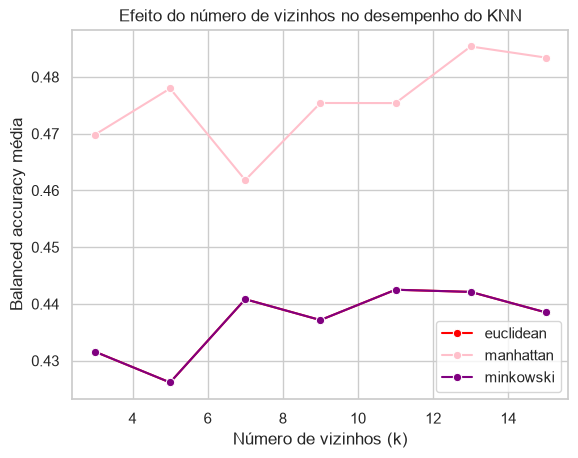

In [21]:
resultados1_uniform = resultados1[resultados1["param_model__weights"] == "uniform"]

sns.lineplot(
    data = resultados1_uniform,
    x = "param_model__n_neighbors",
    y = "mean_test_score",
    hue = "param_model__metric",
    marker = "o",
    palette = ["red","pink", "purple"] 
)

plt.title("Efeito do número de vizinhos no desempenho do KNN")
plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Balanced accuracy média")
plt.legend(loc = "lower right")
plt.show()

Considerando esses parâmetros, a métrica com maior balanced accuracy foi a de distância manhattan, e o aumento do número de vizinhos reflete num pequeno aumento da balanced accuracy.

O processo é repetido considerando a distância dos vizinhos como peso.

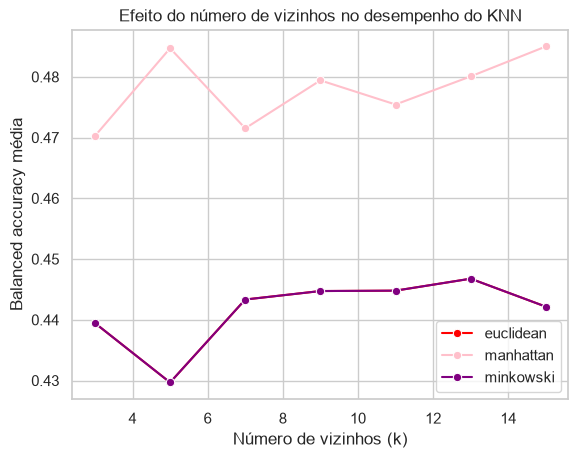

In [22]:
resultados1_distance = resultados1[resultados1["param_model__weights"] == "distance"]

sns.lineplot(
    data = resultados1_distance,
    x = "param_model__n_neighbors",
    y = "mean_test_score",
    hue = "param_model__metric",
    marker = "o",
    palette = ["red","pink", "purple"] 
)

plt.title("Efeito do número de vizinhos no desempenho do KNN")
plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Balanced accuracy média")
plt.legend(loc = "lower right")
plt.show()

Considerando esses parâmetros, a métrica com maior balanced accuracy foi a de distância manhattan.

Esses valores não são muito bons, então o mesmo processo será feito novamente, agora com a normalização dos dados numéricos. A previsão é que o desempenho do modelo será melhor, pois o algoritmo de KNN avalia distâncias entre os atributos, se todos os valores estiverem em escalas muito diferentes essa distância é distorcida.

#### Algoritmo com normalização dos dados numéricos

Para a transformação dos dados, será utilizada a função make_column_transformer para aplicar o StandartScaler nos atributos numéricos e o OneHotEncoder nos atributos categóricos, e depois juntar novamente ambos os atributos transformados.  
O "StandartScaler" ajusta os dados numéricos para que tenham média 0 e desvio padrão 1, então todas as variáveis ficam na mesma escala.
Enquanto isso, o "OneHotEncoder" transforma variáveis categóricas em colunas de 0 e 1, dessa forma, o algoritmo consegue processar numericamente.


In [23]:
preprocessamento2 = make_column_transformer(
    (StandardScaler(), atributos_numericos),
    (OneHotEncoder(), atributo_categorico),
)

Cria-se o pipeline para juntar as duas etapas (de transformação e classificação) de maneira sequencial.

In [24]:
#Aqui se usa o Pipeline do sklearn.pipeline

In [25]:
novo_modelo2 = Pipeline([("scalers", preprocessamento2), ("model", KNeighborsClassifier())])

In [26]:
# Aqui se usa o GridSearchCV do módulo sklearn.model_selection  

NUM_FOLDS2 = 10

espaco_de_busca2 = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"],
}

buscador2 = GridSearchCV(
    novo_modelo2,
    espaco_de_busca2,
    cv=NUM_FOLDS2,
    scoring="balanced_accuracy",
    refit=True,  # reajusta o melhor modelo com todos os dados de treino
    n_jobs = 4,
)

buscador2.fit(X_treino, y_treino)

resultados2 = pd.DataFrame(buscador2.cv_results_)
resultados2

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__metric,param_model__n_neighbors,param_model__weights,params,split0_test_score,split1_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.030300,0.003676,0.023087,0.002094,euclidean,3,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.571099,0.598526,...,0.663956,0.644643,0.647675,0.635453,0.617602,0.661199,0.683872,0.631794,0.033865,37
1,0.030294,0.001664,0.021274,0.002513,euclidean,3,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.574652,0.598489,...,0.645385,0.649313,0.637675,0.618977,0.624547,0.671301,0.667594,0.626828,0.032187,39
2,0.028366,0.002581,0.023527,0.003391,euclidean,5,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.624652,0.584313,...,0.674350,0.603477,0.631462,0.645819,0.631389,0.664254,0.693008,0.633854,0.034623,35
3,0.027564,0.002750,0.023263,0.003564,euclidean,5,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.608901,0.593544,...,0.685668,0.623778,0.648874,0.625453,0.627237,0.707982,0.712180,0.643149,0.041755,21
4,0.026962,0.004158,0.023136,0.002955,euclidean,7,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.603223,0.644240,...,0.672885,0.631579,0.641827,0.649810,0.675015,0.674722,0.669023,0.644414,0.030145,17
5,0.025193,0.002469,0.022126,0.003311,euclidean,7,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.616777,0.623507,...,0.688526,0.638158,0.641930,0.642865,0.671594,0.668246,0.667895,0.644058,0.030104,19
6,0.026156,0.002535,0.023031,0.002981,euclidean,9,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.606081,0.647060,...,0.653617,0.625658,0.628772,0.625921,0.658070,0.688611,0.685865,0.640074,0.031907,30
7,0.026589,0.002265,0.021063,0.001720,euclidean,9,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.603956,0.627060,...,0.676401,0.632237,0.642295,0.619342,0.668904,0.665190,0.679023,0.640117,0.030185,26
8,0.025566,0.003818,0.022286,0.002169,euclidean,11,uniform,"{'model__metric': 'euclidean', 'model__n_neigh...",0.626777,0.614240,...,0.698599,0.646429,0.680439,0.615088,0.681594,0.675190,0.668985,0.652479,0.030543,9
9,0.026440,0.002529,0.022198,0.003089,euclidean,11,distance,"{'model__metric': 'euclidean', 'model__n_neigh...",0.640330,0.627060,...,0.695009,0.659586,0.656184,0.615453,0.661594,0.655190,0.664737,0.647545,0.025993,12


Filtra-se apenas as colunas de interesse para um novo DataFrame.

In [27]:
resultados2.reindex(
    ["mean_test_score", "std_test_score", "param_model__n_neighbors", "param_model__weights", "param_model__metric" ], axis=1
)

,mean_test_score,std_test_score,param_model__n_neighbors,param_model__weights,param_model__metric
0,0.631794,0.033865,3,uniform,euclidean
1,0.626828,0.032187,3,distance,euclidean
2,0.633854,0.034623,5,uniform,euclidean
3,0.643149,0.041755,5,distance,euclidean
4,0.644414,0.030145,7,uniform,euclidean
5,0.644058,0.030104,7,distance,euclidean
6,0.640074,0.031907,9,uniform,euclidean
7,0.640117,0.030185,9,distance,euclidean
8,0.652479,0.030543,11,uniform,euclidean
9,0.647545,0.025993,11,distance,euclidean


Em seguida, são exibidos os melhores parâmetros encontrados e é realizada a previsão da região cortical usando o melhor modelo do "buscador": métrica Manhattan, 15 vizinhos e peso utilizando as distâncias.

As métricas de desempenho são calculadas e é obtida uma acurácia balanceada de 72.50% e uma acurácia de 70.45%.

In [28]:
print(f"Melhores parâmetros: {buscador2.best_params_}")

y_previsto = buscador2.predict(X_teste)
balanced_accuracy2 = balanced_accuracy_score(y_teste, y_previsto)
accuracy2 = accuracy_score(y_teste, y_previsto)

print(f"A balanced accuracy no teste foi de {(balanced_accuracy2*100):.2f}%, enquanto a acurácia foi de {(accuracy2*100):.2f}%")

Melhores parâmetros: {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}
A balanced accuracy no teste foi de 72.51%, enquanto a acurácia foi de 70.45%


Houve um aumento considerável em ambas as métricas devido à normalização dos dados numéricos. No primeiro modelo, sem normalização, a balanced accuracy foi de 48.72%, enquanto a acuracia foi de 51.52%. Depois da normalização esses valores aumentaram 23.79 e 18.93 pontos percentuais, respectivamente.

Agora cria-se mais um gráfico, para isso filtra-se os resultados para considerar apenas as configurações em que "weights = uniform"

In [29]:
print(resultados2.columns.tolist())

['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_model__metric', 'param_model__n_neighbors', 'param_model__weights', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'split5_test_score', 'split6_test_score', 'split7_test_score', 'split8_test_score', 'split9_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']


O gráfico de linhas é criado mostrando como a balanced accuracy média varia conforme o número de vizinhos. As linhas diferentes representam as métricas de distância usadas pelo KNN.

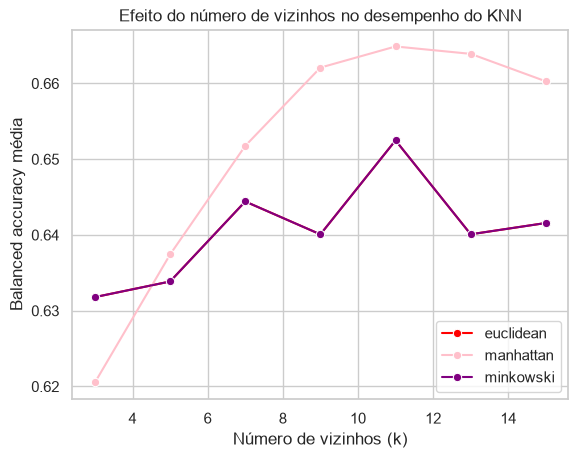

In [30]:
resultados2_uniform = resultados2[resultados2["param_model__weights"] == "uniform"]

sns.lineplot(
    data = resultados2_uniform,
    x = "param_model__n_neighbors",
    y = "mean_test_score",
    hue = "param_model__metric",
    marker = "o",
    palette = ["red","pink", "purple"] 
)

plt.title("Efeito do número de vizinhos no desempenho do KNN")
plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Balanced accuracy média")
plt.legend(loc = "lower right")
plt.show()

Parece estar faltando a linha correspondente à métric minkowski, mas, na verdade, por padrão minkowski utiliza p = 2, e p corresponde ao tipo de distância utilizada para o cálculo, sendo p = 1 para distância manhattan e p = 2 para distância euclidiana. Por isso, nesse caso, o dessempenho da distância minkowski e euclidiana se sobrepõem, elas são iguais. Poderia ser utilizado p = 1,5 para encontrar um "meio-termo" entre as duas, mas por conta do volume de dados esse cálculo seria lento.

No geral, a métrica manhattan apresentou maiores médias de balanced accuracy, com uma tendência mais definida.

Cria-se mais um outro gráfico, agora utilizando os resultados para considerar apenas as configurações em que "weights = distance"

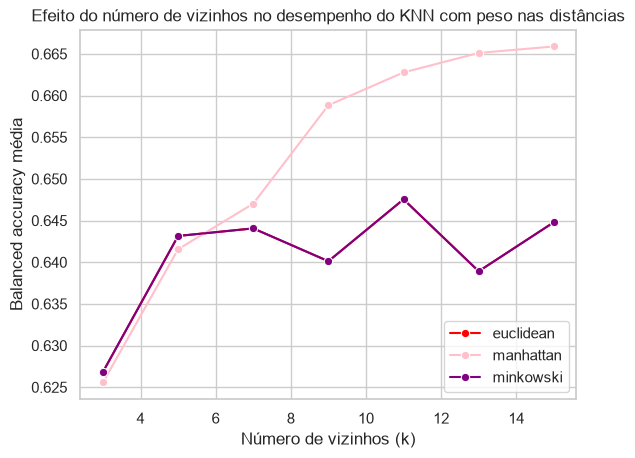

In [31]:
resultados2_distance = resultados2[resultados2["param_model__weights"] == "distance"]

sns.lineplot(
    data = resultados2_distance,
    x = "param_model__n_neighbors",
    y = "mean_test_score",
    hue = "param_model__metric",
    marker = "o",
    palette = ["red", "pink", "purple"] 
)

plt.title("Efeito do número de vizinhos no desempenho do KNN com peso nas distâncias")
plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Balanced accuracy média")
plt.legend(loc = "lower right")
plt.show()

A sobreposição de minkowski e euclidiana também ocorre aqui. Com até 5 vizinhos a balanced accuracy da métrica euclidiana é melhor que a da métrica manhattan, mas a partir disso a manhattan apresenta resultados maiores, com o melhor número de vizinhos sendo 15.

##### Matriz de confusão

Para avaliar o desempenho do modelo, foi criada uma matriz de confusão comparando as classes reais (y_teste) com as classes previstas pelo modelo (y_previsto). No gráfico de calor, os números indicam a quantidade de neurônios qe foram classificados em cada combinação de classe real e classe prevista.
Dessa forma, é possível observar a quantidade de acertos e erros para cada "structure__acronym" e as regiões mais confundidas pelo algoritmo. 

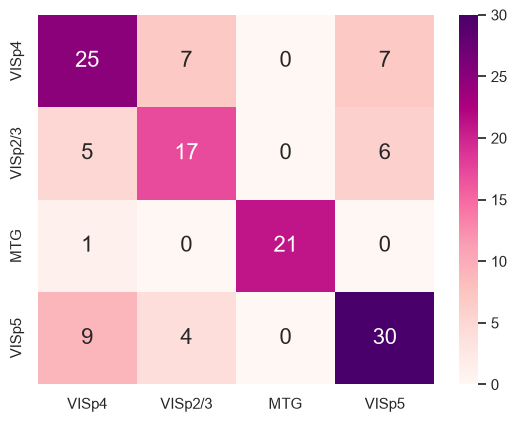

In [32]:
ordem_labels = df_knn["structure__acronym"].unique().tolist()

matriz_conf2 = confusion_matrix(y_teste, y_previsto, labels=ordem_labels)
df_conf2 = pd.DataFrame(matriz_conf2, ordem_labels, ordem_labels)

sns.heatmap(df_conf2, annot=True, annot_kws={"size": 16}, cmap= "RdPu");

A diagonal da matriz de confusão corresponde às regiões corretamente previstas do modelo. No gráfico de calor acima, as cores mais intensas indicam maiores concentrações de previsões, e é justamente na diagonal que estão presentes as cores mais próximas de roxo. Ou seja, o algoritmo teve um elevado desempenho na previsão das regiões cerebrais.
Isso pode ser verificado, também, pela acurácia:

In [33]:
acuracia = accuracy_score(y_teste, y_previsto)

print(f"Acurácia = {(acuracia*100):.2f}%")

Acurácia = 70.45%


### Modelo Baseline

É criado um modelo preditivo extremamente simples para realizar uma comparação com o KNN obtido:

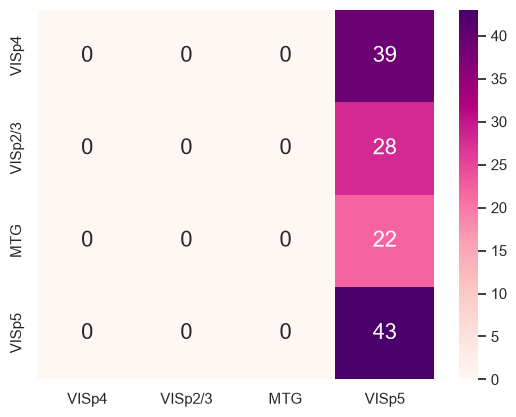

In [34]:
modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino)

y_real = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_real, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16}, cmap= "RdPu");

In [35]:
acuracia = accuracy_score(y_real, y_previsao)
acuracia_balanceada = balanced_accuracy_score(y_real, y_previsao)
print(f"Acurácia = {(acuracia*100):.2f}%")
print(f"Balanced accuracy = {(acuracia_balanceada*100):.2f}%")

Acurácia = 32.58%
Balanced accuracy = 25.00%


A acurácia e a balanced accuracy desse modelo são extremamente baixas. Houve um aumento considerável em ambas as métricas devido à normalização d. No modelo KNN com todos os dados normalizados esses valores são 37.87 e 47.51 pontos percentuais maiores, respectivamente para a acurácia e balanced accuracy.
Uma vez que modelos com acurácia inferior a acurácia do baseline são considerados modelos muito ruins, é possível considerar o modelo KNN bem eficiente se comparado ao baseline.

### Visualização 3D

Para criar uma representação visual adequada do funcionamento do modelo, é utilizado o módulo "BrainRender", uma iniciativa do BrainGlobe Iniciative que cria renderizações neuroanatômicas 3D de alta qualidade[3].  
Nesse caso, são utilizados dois atlas cerebrais provenientes do BrainGlobe para adicionar as malhas de regiões cerebrais na scene criada: o "allen_human_500um", para um cérebro humano, e "allen_mouse_25um", para um cérebro de rato.
Percebe-se no início dos nomes dos atlas o termo "Allen". O BrainGlobe utiliza os mesmos serviços de API que o Allen Brain Atlas, então é possível utilizar os dados de atlas diretamente do Allen Brain Atlas e se torna bem mais fácil utilizar o dataset cell-types_specimen_details com o BrainRender.



In [39]:
#Configurações especificadas na documentação do BrainRender para conseguir abrir nova janela
#Aqui se usa o módulo vedo

vedo.settings.default_backend = "vtk"

#Devido a semente aleatória fixada, o random.choice exibirá apenas um resultado
indice = random.choice(X_teste.index)

#Classifica-se a região cortical desse neurônio
regiao_prevista = buscador2.predict(X_teste.loc[[indice]])[0]

#Através do índice, obtém-se a espécie do doador, a região real do neurônio e suas coordenadas
especie = df_celulas.loc[indice, "donor__species"]
regiao_real = df_celulas.loc[indice, "structure__acronym"]
coordenadas = np.array([
        df_celulas.loc[indice,["csl__x", "csl__y","csl__z"]].to_numpy() #É necessário converter para array
    ])

#Para usar o atlas humano
if especie == "Homo Sapiens":
    
    atlas = "allen_human_500um"
    regiao_total = "Cx"

#Em caso de previsão correta a região aparece como verde
    if regiao_prevista == regiao_real:
        
        titulo = "Identificaçao correta!"
        popup_scene = Scene(atlas_name= atlas, title = titulo )
        popup_scene.add_brain_region(regiao_total, alpha = 0.1)
        popup_scene.add_brain_region(regiao_prevista, color = "green", alpha = 0.7)
        popup_scene.render() #Aperte Esc para sair
        popup_scene.close()

#Caso contrário, a região correta aparece como verde e a prevista como vermelho
    else:
        
        titulo = "Identificaçao incorreta."
        popup_scene = Scene(atlas_name= atlas, title = titulo )
        popup_scene.add_brain_region(regiao_total, alpha = 0.1)
        popup_scene.add_brain_region(regiao_prevista, color = "red", alpha = 0.7)
        popup_scene.add_brain_region(regiao_real, color = "green", alpha = 0.7)
        popup_scene.render() #Aperte Esc para sair
        popup_scene.close()

#Para usar o atlas de rato

else:
    
    atlas = "allen_mouse_25um"
    regiao_total = "CTX"

#Em caso de previsão correta a região aparece verde
    
    if regiao_prevista == regiao_real:

        titulo = "Identificaçao correta!"
        popup_scene = Scene(atlas_name= atlas, title = titulo )
        popup_scene.add_brain_region(regiao_total, alpha = 0.1)
        popup_scene.add_brain_region(regiao_prevista, color = "green", alpha = 0.7)
        points = Points(coordenadas, radius=200, colors="yellow")
        popup_scene.add(points)
        popup_scene.render() #Aperte Esc para sair
        popup_scene.close()

#Caso de previsão incorreta
    
    else:

        titulo = "Identificaçao incorreta."
        popup_scene = Scene(atlas_name= atlas, title = titulo )
        popup_scene.add_brain_region(regiao_total, alpha = 0.1)
        popup_scene.add_brain_region(regiao_prevista, color = "red", alpha = 0.7)
        popup_scene.add_brain_region(regiao_real, color = "green", alpha = 0.7)
        points = Points(coordenadas, radius=250, colors="yellow")
        popup_scene.add(points)
        popup_scene.render() #Aperte Esc para sair
        popup_scene.close()

In [40]:
print(f"""A região prevista para esse neurônio é {regiao_prevista}
A região real desse neurônio é {regiao_real}
As coordenadas reais desse neurônio são:{coordenadas}""")

A região prevista para esse neurônio é VISp5
A região real desse neurônio é VISp5
As coordenadas reais desse neurônio são:[[9629.04463518 1669.04918009 8718.95488007]]


## Conclusão

O projeto permitiu aplicar o algoritmo KNN a dados reais de neurônios, buscando prever suas estruturas cerebrais a partir de características eletrofisiológicas e da espécie. A normalização dos atributos teve um impacto significativo no desempenho, aumentando a balanced accuracy de 48,72% para 72,51% e a acurácia de 51,52% para 70,45%.

A validação cruzada e a otimização de hiperparâmetros permitiram comparar diferentes configurações do modelo sem causar vazamento de dados. A matriz de confusão possibilitou analisar os principais acertos e erros da classificação, enquanto o Brainrender permitiu visualizar tridimensionalmente a localização real e a prevista dos neurônios.

Assim, o projeto mostrou como a ciência de dados pode auxiliar na identificação de padrões entre características dos neurônios e sua localização cerebral, destacando a importância do pré-processamento e da escolha dos parâmetros do modelo.

## Uso de IA

Para a produção deste trabalho, foi utilizada a Inteligência Artificial como ferramenta complementar de revisão. O uso da tecnologia se concentrou, especificamente, na análise e discussão dos erros apresentados ao longo do desenvolvimento do projeto, bem como na formulação de sugestões fundamentadas para os próximos passos. Para a produção de alguns textos como a descrição dos atributos individualmente, o README do github e as referências a IA também foi utilizada.

O link para a conversa no modelo de IA utilizado, o chatgot, se encontra aqui: https://chatgpt.com/share/6ab102c3-35e8-83e9-a7a0-7852fab75e99

## Referências

[1] AMAZON WEB SERVICES. Classificação multiclasse. Amazon Machine Learning, s.d.

[2] BRAIN GLOBE. brainrender. GitHub, s.d.

[3] BRAIN GLOBE. brainrender. PyPI, s.d.

[4] CASSAR, Daniel. ATP-203 - 1.1 - Tratamento de dados com pandas. Notebook, s.d.

[5] CASSAR, Daniel. ATP-203 - 2.1 - Aprendizado de máquina, k-NN e métricas. Notebook, s.d.

[6] CASSAR, Daniel. ATP-203 - 2.2 - Divisão de dados em treino e teste. Notebook, s.d.

[7] CASSAR, Daniel. ATP-203 - 3.0 - Modelo linear e baseline. Notebook, s.d.

[8] CASSAR, Daniel. ATP-203 - 5.0 - Classificação binária. Notebook, s.d.

[9] CASSAR, Daniel. ATP-203 - 6.0 - Validação cruzada e otimização de hiperparâmetros. Notebook, s.d.

[10] CLAUDI, F.; TYSON, A. L.; PETRUCCO, L.; MARGRIE, T. W.; PORTUGUES, R.; BRANCO, T. Visualizing anatomically registered data with brainrender. eLife, v. 10, e65751, 2021. DOI: 10.7554/eLife.65751.

[11] DIGITALE, E. Brain tumors make electrical connections to healthy neurons, Stanford study finds. Stanford Medicine, 2019.

[12] GILBERT, S. F. Tissue Architecture of the Central Nervous System. In: Developmental Biology. 6. ed. Sinauer Associates, 2000.

[13] INRIA. Using numerical and categorical variables together — Scikit-learn course. Scikit-learn MOOC, s.d.

[14] MAFFAZIOLI, U. Machine Learning | Algoritmo kNN. Medium, s.d.

[15] MACHINE LEARNING MASTERY. How to Use the ColumnTransformer for Data Preparation. s.d.

[16] MIT. Study finds a striking difference between neurons of humans and other mammals. MIT News, 2021.

[17] SCHARTZMAN, H. E. The Neurobiology of Epilepsy. Current Neurology and Neuroscience Reports, 2007. DOI: 10.1007/s11910-007-0053-z.

[18] SCIKIT-LEARN. Metrics and scoring: quantifying the quality of predictions. s.d.

[19] STACK OVERFLOW. How to normalize validation set in GridSearchCV separately from training set? s.d.

[20] ZHANG et al. Comparison Between Human and Rodent Neurons for Persistent Activity Performance. Frontiers in Systems Neuroscience, 2021. DOI: 10.3389/fnsys.2021.628839.